# Spam Classification Training Pipeline




In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from feature_engineering import engineer_features

### 1. Load & Clean Raw Data


In [2]:
RAW_DATASET_PATH = "dataset/raw/emails.csv"

df = pd.read_csv(RAW_DATASET_PATH, encoding="latin1")

df = df.drop_duplicates(keep="first").reset_index(drop=True)

print(f"Dataset shape after deduplication: {df.shape}")

Dataset shape after deduplication: (5695, 2)


### 2. Apply Custom Feature Engineering


In [ ]:

df_eng = engineer_features(df, text_column="text")

display(df_eng.head())

,text,spam,num_chars,num_words,num_sentences,log_num_chars,log_num_words,log_num_sentences,num_digits,num_special,has_link,has_phone,num_exclamations,num_questions,text_clean
0,Subject: naturally irresistible your corporate...,1,1484,325,11,7.303170,5.786897,2.484907,3,136,0,0,0,0,naturally irresistible corporate identity lt r...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,6.395262,4.510860,0.693147,0,1,0,0,0,0,stock trading gunslinger fanny merrill muzo co...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,6.107023,4.488636,1.609438,10,8,0,0,0,0,unbelievable new homes made easy im wanting sh...
3,Subject: 4 color printing special request add...,1,500,99,5,6.216606,4.605170,1.791759,30,25,0,0,2,0,4 color printing special request additional in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,5.463832,3.988984,2.302585,0,13,0,0,1,1,money get software cds software compatibility ...


### 3. Train / Test Split


In [ ]:
X = df_eng.drop(columns=["spam", "text"])  
y = df_eng["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set Shapes:", X_train.shape, y_train.shape)
print("Test Set Shapes:", X_test.shape, y_test.shape)

Training Set Shapes: (4556, 13) (4556,)
Test Set Shapes: (1139, 13) (1139,)


### 4. Build Preprocessing Pipeline

Combine `TfidfVectorizer` (for `text_clean`) with `StandardScaler` (for our numeric dense features) using a `ColumnTransformer`.


In [5]:
# Identify columns for each transformer
text_features = "text_clean"
numeric_features = [
    "log_num_chars",
    "log_num_words",
    "log_num_sentences",
    "num_digits",
    "num_special",
    "has_link",
    "has_phone",
    "num_exclamations",
    "num_questions",
]

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # The textual features get TF-IDF processing
        # Note: We already stripped stopwords & fixed Enron leakage in the feature engineering step
        (
            "tfidf",
            TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
            text_features,
        ),
        # The dense numeric features get standardized
        ("scaler", StandardScaler(), numeric_features),
    ],
    remainder="drop",  # Drop raw unscaled columns like num_chars (we use the log versions)
)

# Fit-transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Features shape:", X_train_processed.shape)

Processed Training Features shape: (4556, 5009)


### 5. Train the model


In [12]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.model_selection import cross_val_predict, GridSearchCV

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.pipeline import Pipeline

import joblib

In [7]:
PROJECT_ROOT_DIR = "."
IMG_PATH = os.path.join(PROJECT_ROOT_DIR, "images", "model_selection")
os.makedirs(IMG_PATH, exist_ok=True)


def save_fig(fig_id, fig_extension="png", resolution=300):
    path = os.path.join(IMG_PATH, fig_id + "." + fig_extension)
    plt.tight_layout()
    print("Saving figure", fig_id)
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [8]:
def evaluate_pipeline(pipeline, pipeline_name, save_figure=True):
    classes = ["ham", "spam"]

    y_cv_pred = cross_val_predict(pipeline, X_train, y_train, cv=3)

    print(f"==== CV Predict : {pipeline_name} ====")
    print(classification_report(y_train, y_cv_pred, target_names=classes))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    cm_cv = confusion_matrix(y_train, y_cv_pred)
    ConfusionMatrixDisplay(cm_cv, display_labels=classes).plot(
        ax=axes[0, 0], cmap="Blues"
    )
    axes[0, 0].set_title("CV Confusion Matrix")

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)

    print(f"==== Train Predict : {pipeline_name} ====")
    print(classification_report(y_train, y_train_pred, target_names=classes))

    cm_train = confusion_matrix(y_train, y_train_pred)
    ConfusionMatrixDisplay(cm_train, display_labels=classes).plot(
        ax=axes[0, 1], cmap="Blues"
    )
    axes[0, 1].set_title("Train Confusion Matrix")

    y_test_pred = pipeline.predict(X_test)

    print(f"==== Test Predict : {pipeline_name} ====")
    print(classification_report(y_test, y_test_pred, target_names=classes))

    cm_test = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm_test, display_labels=classes).plot(
        ax=axes[1, 0], cmap="Blues"
    )
    axes[1, 0].set_title("Test Confusion Matrix")

    axes[1, 1].axis("off")

    fig.suptitle(pipeline_name, fontsize=16)
    plt.tight_layout()
    if save_figure:
        save_fig(f"{pipeline_name}_confusion_mat")
    plt.show()

==== CV Predict : LogisticRegression ====
              precision    recall  f1-score   support

         ham       0.96      0.99      0.98      3462
        spam       0.98      0.87      0.92      1094

    accuracy                           0.96      4556
   macro avg       0.97      0.93      0.95      4556
weighted avg       0.96      0.96      0.96      4556

==== Train Predict : LogisticRegression ====
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      3462
        spam       0.99      0.95      0.97      1094

    accuracy                           0.99      4556
   macro avg       0.99      0.97      0.98      4556
weighted avg       0.99      0.99      0.99      4556

==== Test Predict : LogisticRegression ====
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       865
        spam       0.98      0.91      0.94       274

    accuracy                           0.97      11

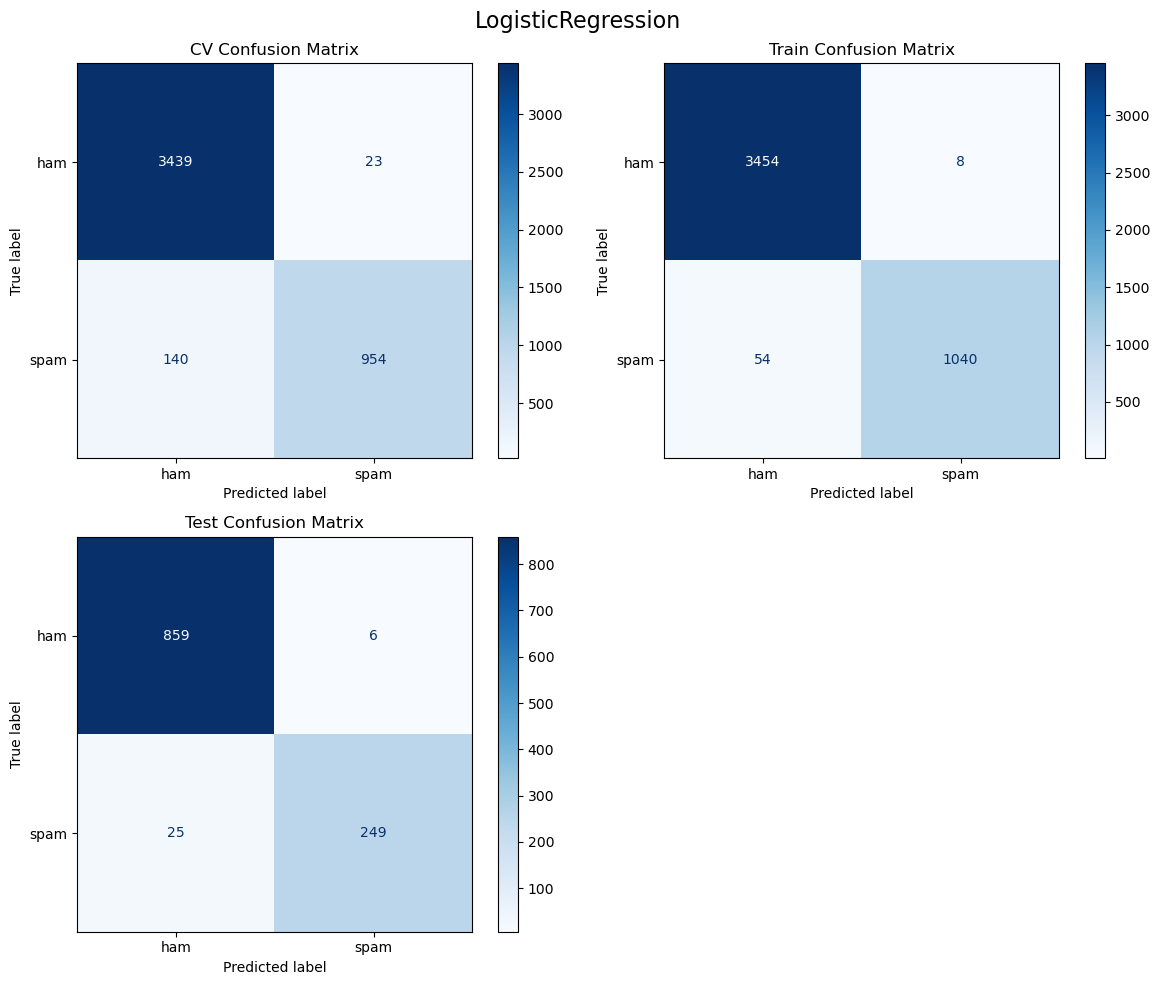

==== CV Predict : DecisionTreeClassifier ====
              precision    recall  f1-score   support

         ham       0.95      0.95      0.95      3462
        spam       0.84      0.86      0.85      1094

    accuracy                           0.93      4556
   macro avg       0.90      0.90      0.90      4556
weighted avg       0.93      0.93      0.93      4556

==== Train Predict : DecisionTreeClassifier ====
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00      3462
        spam       1.00      1.00      1.00      1094

    accuracy                           1.00      4556
   macro avg       1.00      1.00      1.00      4556
weighted avg       1.00      1.00      1.00      4556

==== Test Predict : DecisionTreeClassifier ====
              precision    recall  f1-score   support

         ham       0.96      0.96      0.96       865
        spam       0.86      0.89      0.88       274

    accuracy                           

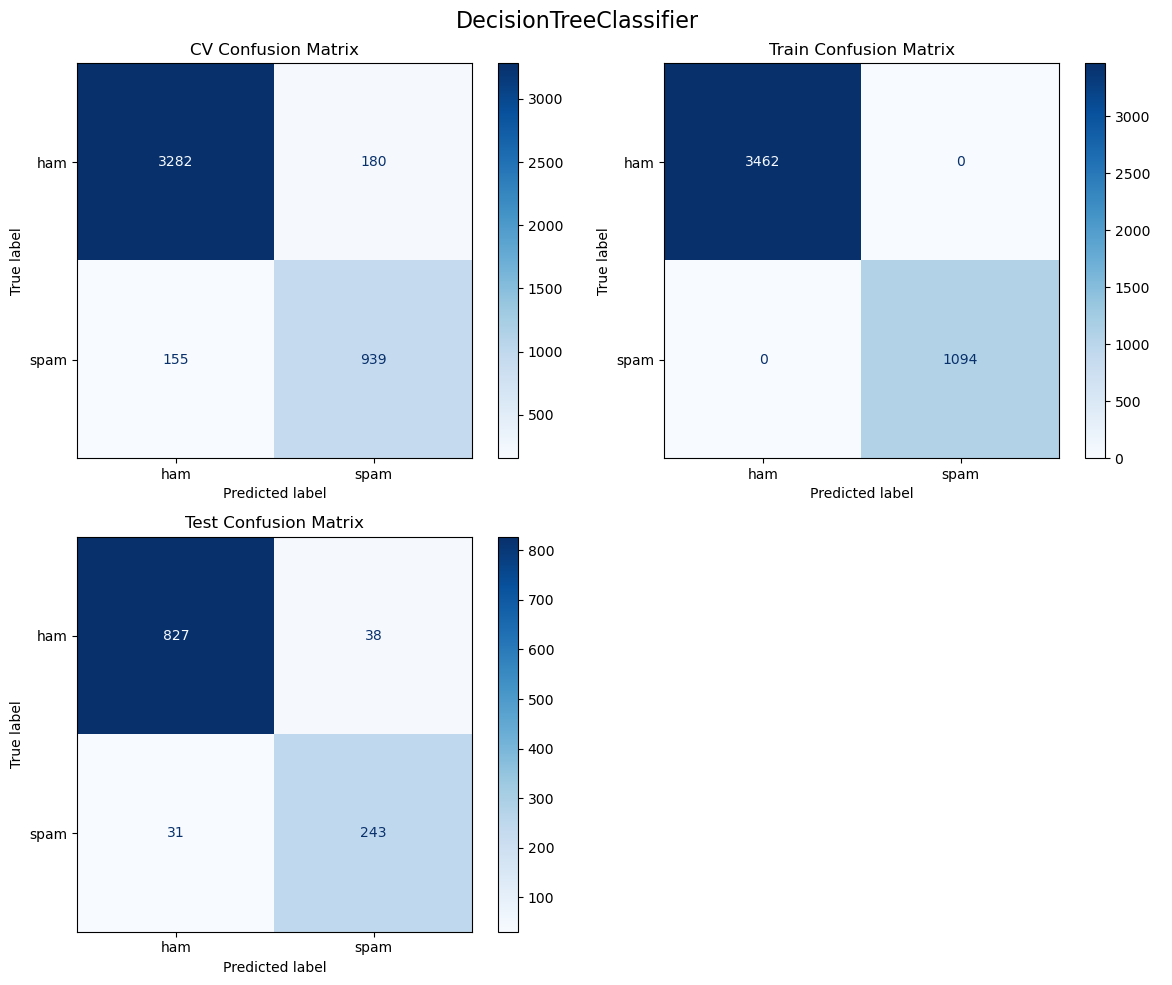

==== CV Predict : SVM ====
              precision    recall  f1-score   support

         ham       0.98      0.97      0.97      3462
        spam       0.90      0.93      0.91      1094

    accuracy                           0.96      4556
   macro avg       0.94      0.95      0.94      4556
weighted avg       0.96      0.96      0.96      4556

==== Train Predict : SVM ====
              precision    recall  f1-score   support

         ham       1.00      0.98      0.99      3462
        spam       0.95      0.99      0.97      1094

    accuracy                           0.98      4556
   macro avg       0.97      0.99      0.98      4556
weighted avg       0.99      0.98      0.98      4556

==== Test Predict : SVM ====
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       865
        spam       0.92      0.96      0.94       274

    accuracy                           0.97      1139
   macro avg       0.95      0.96      0.9

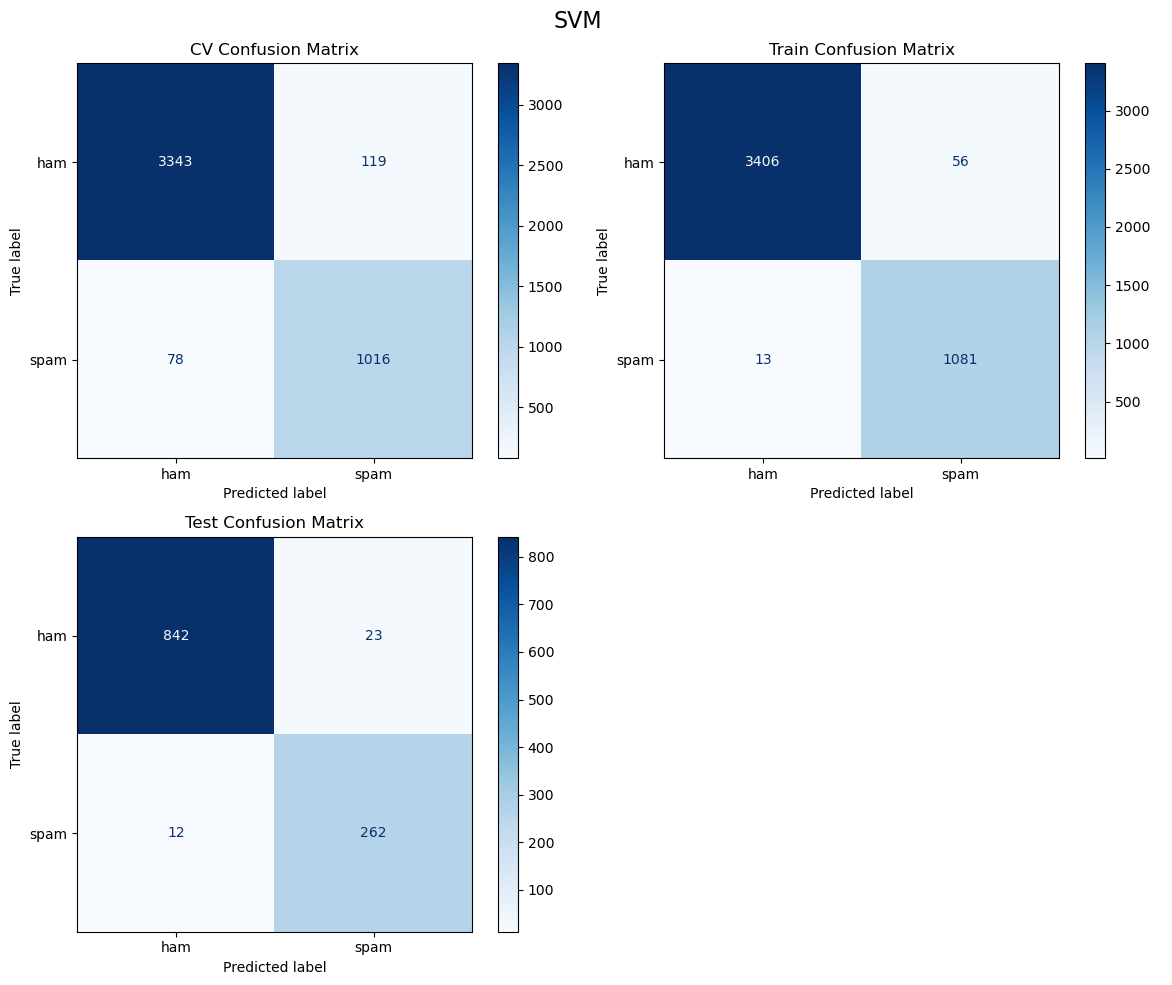

==== CV Predict : KNN ====
              precision    recall  f1-score   support

         ham       0.95      0.97      0.96      3462
        spam       0.90      0.84      0.87      1094

    accuracy                           0.94      4556
   macro avg       0.92      0.90      0.91      4556
weighted avg       0.94      0.94      0.94      4556

==== Train Predict : KNN ====
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98      3462
        spam       0.95      0.89      0.92      1094

    accuracy                           0.96      4556
   macro avg       0.96      0.94      0.95      4556
weighted avg       0.96      0.96      0.96      4556

==== Test Predict : KNN ====
              precision    recall  f1-score   support

         ham       0.94      0.96      0.95       865
        spam       0.88      0.81      0.84       274

    accuracy                           0.93      1139
   macro avg       0.91      0.89      0.9

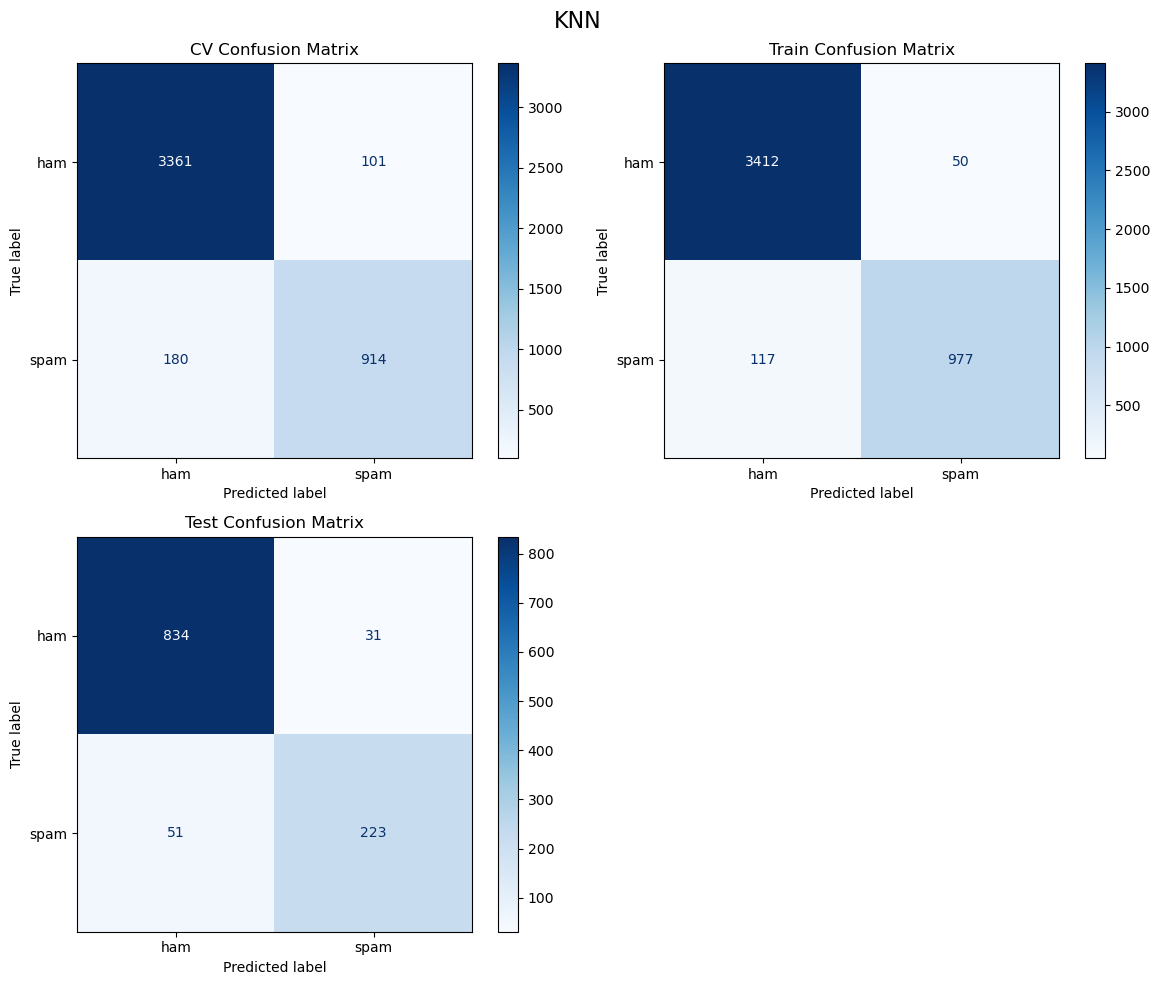

In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTreeClassifier": DecisionTreeClassifier(class_weight="balanced"),
    "SVM": SVC(kernel="rbf", class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
}

for model_name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    evaluate_pipeline(pipe, model_name)

In [17]:
full_pipeline = Pipeline([("prep", preprocessor), ("svm", SVC(probability=True))])

param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.01, 0.1, 1, 10, 100]},
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.001],
    },
]

grid = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svm__C': [0.01, 0.1, ...], 'svm__kernel': ['linear']}, {'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...], 'svm__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

==== CV Predict : tuned_SVM ====
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      3462
        spam       0.98      0.96      0.97      1094

    accuracy                           0.99      4556
   macro avg       0.99      0.98      0.98      4556
weighted avg       0.99      0.99      0.99      4556

==== Train Predict : tuned_SVM ====
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00      3462
        spam       1.00      1.00      1.00      1094

    accuracy                           1.00      4556
   macro avg       1.00      1.00      1.00      4556
weighted avg       1.00      1.00      1.00      4556

==== Test Predict : tuned_SVM ====
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       865
        spam       0.99      0.97      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99 

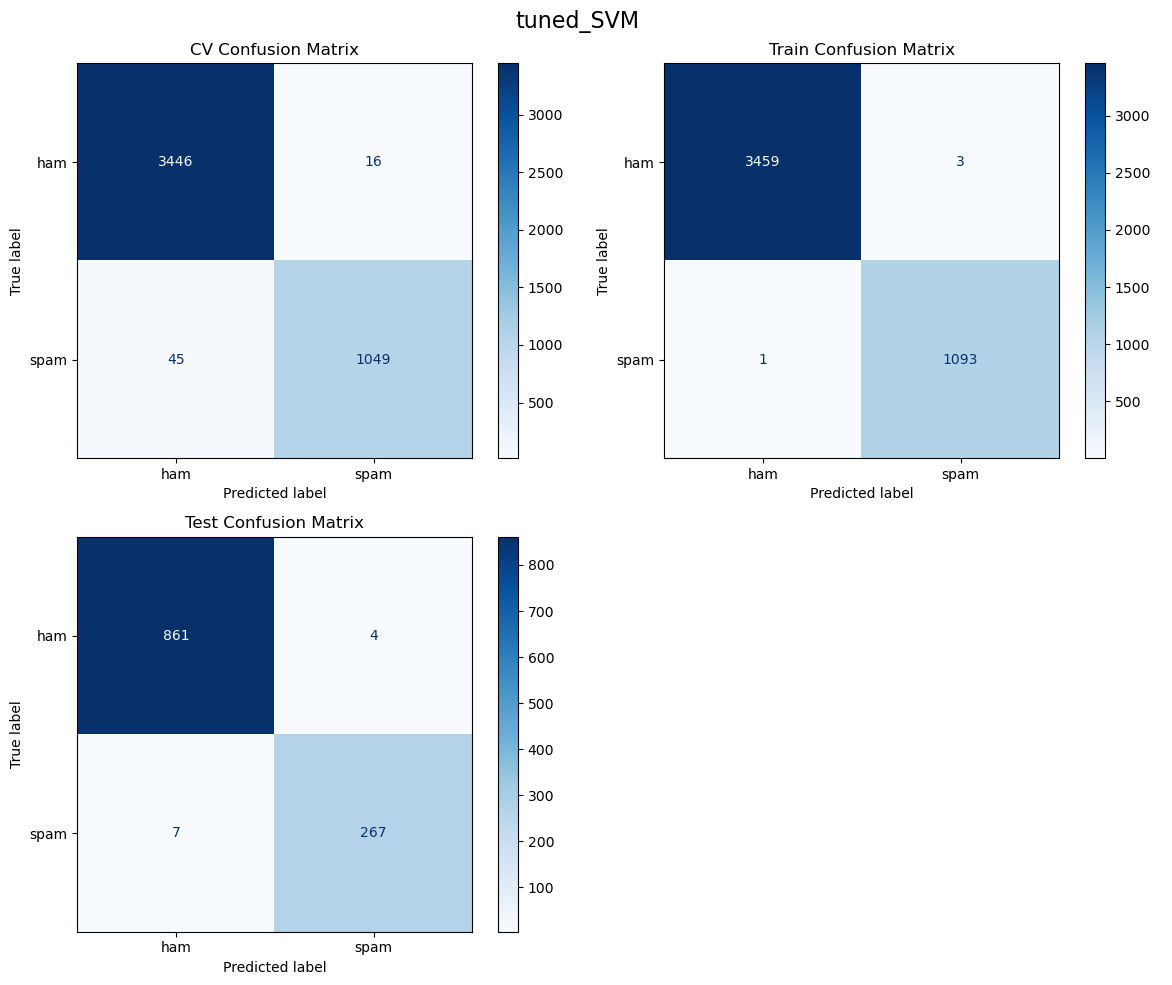

In [18]:
evaluate_pipeline(grid.best_estimator_, "tuned_SVM")

In [20]:
joblib.dump(grid.best_estimator_, f"models/svm_pipeline.joblib")

['models/svm_pipeline.joblib']